In [1]:
import os
import sys
import wandb
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F

sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'scripts'))

In [2]:
from model import GraphSAGENet
from process_multigraphs import DataProcessor
from train import train_epoch_full_graph, evaluate_full_graph
from inspect_graph import graph_metrics, pyg_to_nx, plot_3d_graph, plot_degree_ccdf, plot_link_length_hist

In [3]:
data_path = 'D:\Minerva/Senior Year/Capstone/DM_FIREbox_fresh/data/firebox_data/FIREbox_z=0.txt'
data_processor_kdtree = DataProcessor(file_path=data_path)
preliminary_data_kdtree = data_processor_kdtree.load_data()

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_18528\4202208803.py:1: SyntaxWarning: invalid escape sequence '\M'
  data_path = 'D:\Minerva/Senior Year/Capstone/DM_FIREbox_fresh/data/firebox_data/FIREbox_z=0.txt'


In [4]:
data_processor_kdtree.create_graph_data(graph_type='kdtree', include_lg_Mstar=True, stratify_bins=10, standardize=True)
data_kdtree = data_processor_kdtree.data

print(f'Log Halo Mass Range in training set: {min(data_kdtree.y[data_kdtree.train_mask])} to {max(data_kdtree.y[data_kdtree.train_mask])}')
print(f'Log Halo Mass Range in test set: {min(data_kdtree.y[data_kdtree.test_mask])} to {max(data_kdtree.y[data_kdtree.test_mask])}')
print(f'Mean Log halo mass in training set: {data_kdtree.y[data_kdtree.train_mask].mean():.4f}')
print(f'Mean Log halo mass in test set: {data_kdtree.y[data_kdtree.test_mask].mean():.4f}')


Log Halo Mass Range in training set: tensor([9.5015]) to tensor([13.0780])
Log Halo Mass Range in test set: tensor([9.5013]) to tensor([12.6850])
Mean Log halo mass in training set: 10.0732
Mean Log halo mass in test set: 10.0604


In [5]:
data_processor_ws = DataProcessor(file_path=data_path)
preliminary_data_ws = data_processor_ws.load_data()
data_ws = data_processor_ws.create_graph_data(k=10,graph_type='ws', include_lg_Mstar=True, stratify_bins=10, 
                                    standardize=True, ws_beta=0.1)

d:\Minerva\Senior Year\Capstone\DM_FIREbox_fresh\scripts\form_graphs.py:100: RuntimeWarning: overflow encountered in exp
  weight = np.exp(- (dists / (radii[edge_list[:,0]] + radii[edge_list[:,1]] + 1e-8)) / lambda_decay)


In [6]:
data_processor_ba = DataProcessor(file_path=data_path)
preliminary_data_ba = data_processor_ba.load_data()
data_ba = data_processor_ba.create_graph_data(k=10,graph_type='ba',include_lg_Mstar=True, stratify_bins=10, 
                                    standardize=True)

## Graph Inspection

### KDTree Graph

In [7]:
# Convert to NetworkX
G_kdtree = pyg_to_nx(data_kdtree)

# Compute metrics
metrics_kdtree = graph_metrics(G_kdtree)
print("KDTree Graph Metrics:")
print(f"  Nodes: {metrics_kdtree['N']}")
print(f"  Edges: {metrics_kdtree['E']}")
print(f"  Mean Degree: {metrics_kdtree['deg_mean']:.2f}")
print(f"  Degree Variance: {metrics_kdtree['deg_var']:.2f}")
print(f"  Max Degree: {metrics_kdtree['deg_max']}")
print(f"  Avg Clustering: {metrics_kdtree['avg_clustering']:.4f}")
print(f"\nTop 5 Hubs: {metrics_kdtree['top_hubs'][:5]}")


KDTree Graph Metrics:
  Nodes: 2031
  Edges: 173707
  Mean Degree: 171.06
  Degree Variance: 5017.74
  Max Degree: 366
  Avg Clustering: 0.6521

Top 5 Hubs: [(481, 366), (1721, 362), (1778, 345), (934, 343), (1299, 341)]


In [8]:
plot_3d_graph(G_kdtree)

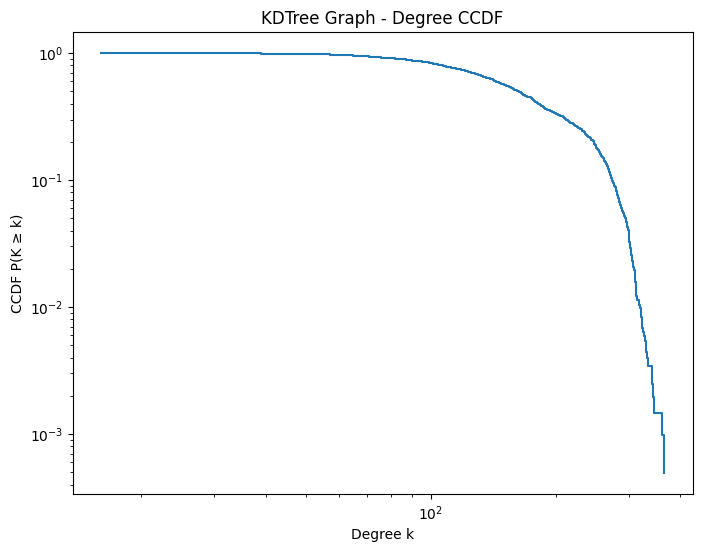

In [9]:
# Plot degree CCDF
fig, ax = plt.subplots(figsize=(8, 6))
plot_degree_ccdf(G_kdtree, ax=ax)
ax.set_title("KDTree Graph - Degree CCDF")
plt.show()


### Watts-Strogatz Graph


In [10]:
# Convert to NetworkX
G_ws = pyg_to_nx(data_ws)

# Compute metrics
metrics_ws = graph_metrics(G_ws)
print("Watts-Strogatz Graph Metrics:")
print(f"  Nodes: {metrics_ws['N']}")
print(f"  Edges: {metrics_ws['E']}")
print(f"  Mean Degree: {metrics_ws['deg_mean']:.2f}")
print(f"  Degree Variance: {metrics_ws['deg_var']:.2f}")
print(f"  Max Degree: {metrics_ws['deg_max']}")
print(f"  Avg Clustering: {metrics_ws['avg_clustering']:.4f}")
print(f"\nTop 5 Hubs: {metrics_ws['top_hubs'][:5]}")


Watts-Strogatz Graph Metrics:
  Nodes: 2031
  Edges: 15027
  Mean Degree: 14.80
  Degree Variance: 31.71
  Max Degree: 73
  Avg Clustering: 0.4622

Top 5 Hubs: [(1, 73), (5, 69), (4, 68), (0, 64), (2, 63)]


In [11]:
plot_3d_graph(G_ws)

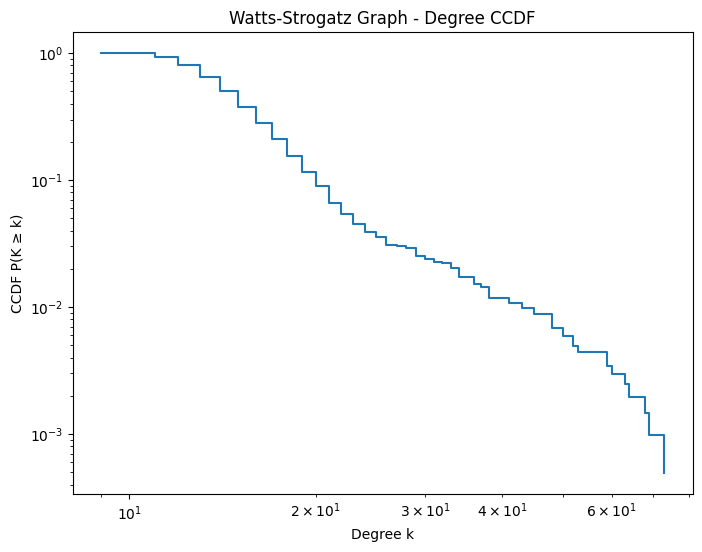

In [12]:
# Plot degree CCDF
fig, ax = plt.subplots(figsize=(8, 6))
plot_degree_ccdf(G_ws, ax=ax)
ax.set_title("Watts-Strogatz Graph - Degree CCDF")
plt.show()


### Barabasi Albert

In [7]:
# Convert to NetworkX
G_ba = pyg_to_nx(data_ba)

# Compute metrics
metrics_ba = graph_metrics(G_ba)
print("Barabási-Albert Graph Metrics:")
print(f"  Nodes: {metrics_ba['N']}")
print(f"  Edges: {metrics_ba['E']}")
print(f"  Mean Degree: {metrics_ba['deg_mean']:.2f}")
print(f"  Degree Variance: {metrics_ba['deg_var']:.2f}")
print(f"  Max Degree: {metrics_ba['deg_max']}")
print(f"  Avg Clustering: {metrics_ba['avg_clustering']:.4f}")
print(f"\nTop 5 Hubs: {metrics_ba['top_hubs'][:5]}")


Barabási-Albert Graph Metrics:
  Nodes: 2031
  Edges: 10140
  Mean Degree: 9.99
  Degree Variance: 2859.47
  Max Degree: 1305
  Avg Clustering: 0.5515

Top 5 Hubs: [(1, 1305), (0, 1024), (4, 815), (6, 794), (2, 696)]


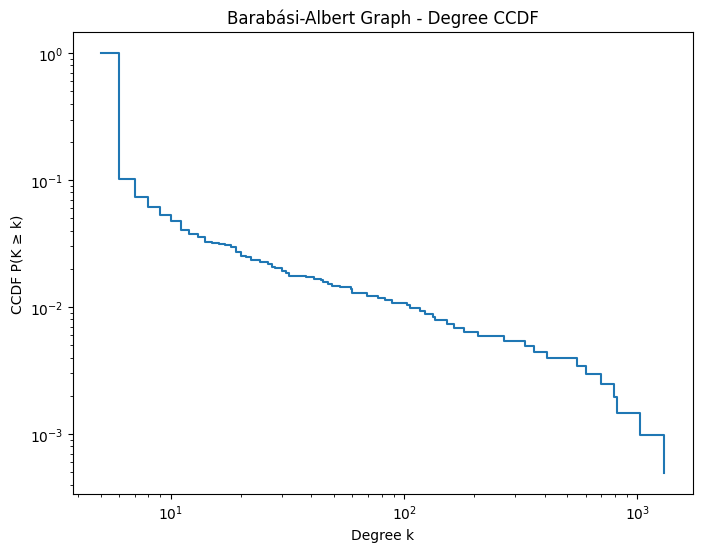

In [8]:
# Plot degree CCDF
fig, ax = plt.subplots(figsize=(8, 6))
plot_degree_ccdf(G_ba, ax=ax)
ax.set_title("Barabási-Albert Graph - Degree CCDF")
plt.show()


## Comparison: Degree CCDF for All Graphs


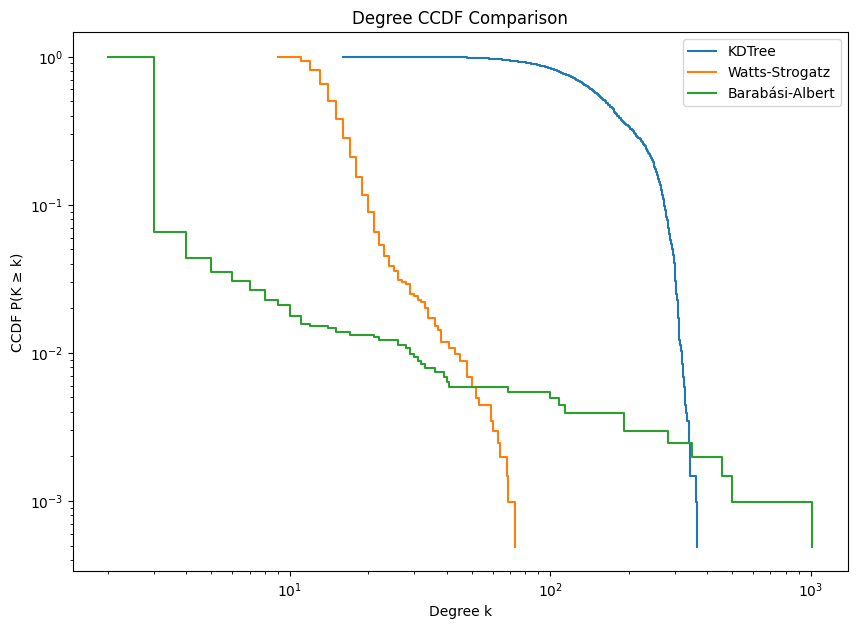

In [17]:
# Compare degree distributions
fig, ax = plt.subplots(figsize=(10, 7))
plot_degree_ccdf(G_kdtree, ax=ax)
plot_degree_ccdf(G_ws, ax=ax)
plot_degree_ccdf(G_ba, ax=ax)
ax.set_title("Degree CCDF Comparison")
ax.legend(['KDTree', 'Watts-Strogatz', 'Barabási-Albert'])
plt.show()


In [29]:
num_layers = 3
hidden_channels = 64
mlp_hidden = 128
learning_rate = 0.001
num_epochs = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [18]:
# Training loop
best_val_rmse = float('inf')
train_losses = []
val_rmses = []
val_maes = []

for epoch in range(num_epochs):
    # Training
    train_loss = train_epoch_full_graph(model, optimizer, data_kdtree, device)
    train_losses.append(train_loss)
    
    # Evaluation
    val_rmse, val_mae, _, _ = evaluate_full_graph(model, data_kdtree, device)
    val_rmses.append(val_rmse)
    val_maes.append(val_mae)
    
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        # Save best model
        torch.save(model.state_dict(), "../logs/best_model.pt")
    if epoch % 10 == 0:
        print(f'Epoch {epoch:03d}, Train Loss: {train_loss:.4f}, Val RMSE: {val_rmse:.4f}, Val MAE: {val_mae:.4f}')

print(f'Best validation RMSE: {best_val_rmse:.4f}')


Epoch 000, Train Loss: 102.2635, Val RMSE: 9.8868, Val MAE: 9.8726
Epoch 010, Train Loss: 70.4298, Val RMSE: 8.1430, Val MAE: 8.1240
Epoch 020, Train Loss: 42.1862, Val RMSE: 6.1600, Val MAE: 6.1358
Epoch 030, Train Loss: 16.1070, Val RMSE: 3.5400, Val MAE: 3.4985
Epoch 040, Train Loss: 1.6079, Val RMSE: 0.5532, Val MAE: 0.3915
Epoch 050, Train Loss: 2.0051, Val RMSE: 0.9579, Val MAE: 0.8782
Epoch 060, Train Loss: 1.2088, Val RMSE: 0.5837, Val MAE: 0.3840
Epoch 070, Train Loss: 0.8748, Val RMSE: 0.4436, Val MAE: 0.2932
Epoch 080, Train Loss: 0.7504, Val RMSE: 0.1931, Val MAE: 0.1238
Epoch 090, Train Loss: 0.5957, Val RMSE: 0.1698, Val MAE: 0.1215
Best validation RMSE: 0.1601


<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_34708\3732275159.py:8: SyntaxWarning: invalid escape sequence '\l'
  ax[0].set_xlabel('True $\log M_{halo}$')
C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_34708\3732275159.py:9: SyntaxWarning: invalid escape sequence '\l'
  ax[0].set_ylabel('Predictions $\log M_{halo}$')
C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_34708\3732275159.py:17: SyntaxWarning: invalid escape sequence '\l'
  ax[1].set_xlabel('True $\log M_{halo}$')


Getting predictions for the entire dataset...


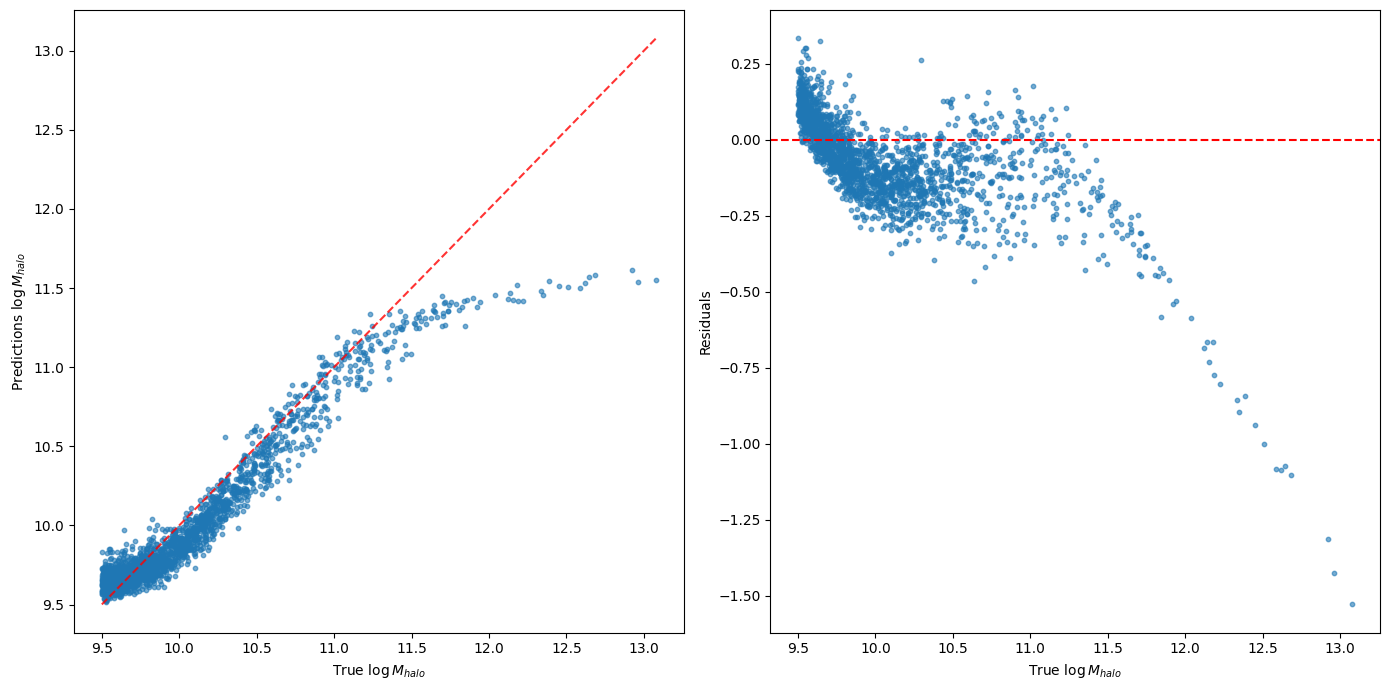

In [19]:
print("Getting predictions for the entire dataset...")
all_predictions = model.predict(data_kdtree, device)
all_true_values = data_kdtree.y.view(-1).cpu()
residuals = all_predictions - all_true_values

fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].scatter(all_true_values, all_predictions, alpha=0.6, s=10)
ax[0].set_xlabel('True $\log M_{halo}$')
ax[0].set_ylabel('Predictions $\log M_{halo}$')

min_val = min(all_true_values.min(), all_predictions.min())
max_val = max(all_true_values.max(), all_predictions.max())
ax[0].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)

ax[1].scatter(all_true_values, residuals, alpha=0.6, s=10)
ax[1].axhline(y=0, color='r', linestyle='--')
ax[1].set_xlabel('True $\log M_{halo}$')
ax[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

In [27]:
# Training loop
best_val_rmse_ws = float('inf')
train_losses_ws = []
val_rmses_ws = []
val_maes_ws = []

for epoch in range(num_epochs):
    # Training
    train_loss = train_epoch_full_graph(model, optimizer, data_ws, device)
    train_losses_ws.append(train_loss)
    
    # Evaluation
    val_rmse, val_mae, _, _ = evaluate_full_graph(model, data_ws, device)
    val_rmses_ws.append(val_rmse)
    val_maes_ws.append(val_mae)
    
    if val_rmse < best_val_rmse_ws:
        best_val_rmse_ws = val_rmse
        # Save best model
        torch.save(model.state_dict(), "../logs/best_model.pt")
    if epoch % 10 == 0:
        print(f'Epoch {epoch:03d}, Train Loss: {train_loss:.4f}, Val RMSE: {val_rmse:.4f}, Val MAE: {val_mae:.4f}')

print(f'Best validation RMSE: {best_val_rmse_ws:.4f}')


Epoch 000, Train Loss: 0.0368, Val RMSE: 1.1499, Val MAE: 1.1463
Epoch 010, Train Loss: 0.0378, Val RMSE: 1.2016, Val MAE: 1.1978
Epoch 020, Train Loss: 0.0395, Val RMSE: 1.1859, Val MAE: 1.1826
Epoch 030, Train Loss: 0.0393, Val RMSE: 1.1878, Val MAE: 1.1843
Epoch 040, Train Loss: 0.0322, Val RMSE: 1.2043, Val MAE: 1.2011
Epoch 050, Train Loss: 0.0315, Val RMSE: 1.1484, Val MAE: 1.1447
Epoch 060, Train Loss: 0.0345, Val RMSE: 1.1755, Val MAE: 1.1720
Epoch 070, Train Loss: 0.0319, Val RMSE: 1.1649, Val MAE: 1.1612
Epoch 080, Train Loss: 0.0318, Val RMSE: 1.1777, Val MAE: 1.1736
Epoch 090, Train Loss: 0.0302, Val RMSE: 1.1463, Val MAE: 1.1431
Best validation RMSE: 1.1361


<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_9112\1853337478.py:8: SyntaxWarning: invalid escape sequence '\l'
  ax[0].set_xlabel('True $\log M_{halo}$')
C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_9112\1853337478.py:9: SyntaxWarning: invalid escape sequence '\l'
  ax[0].set_ylabel('Predictions $\log M_{halo}$')
C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_9112\1853337478.py:17: SyntaxWarning: invalid escape sequence '\l'
  ax[1].set_xlabel('True $\log M_{halo}$')


Getting predictions for the entire dataset...


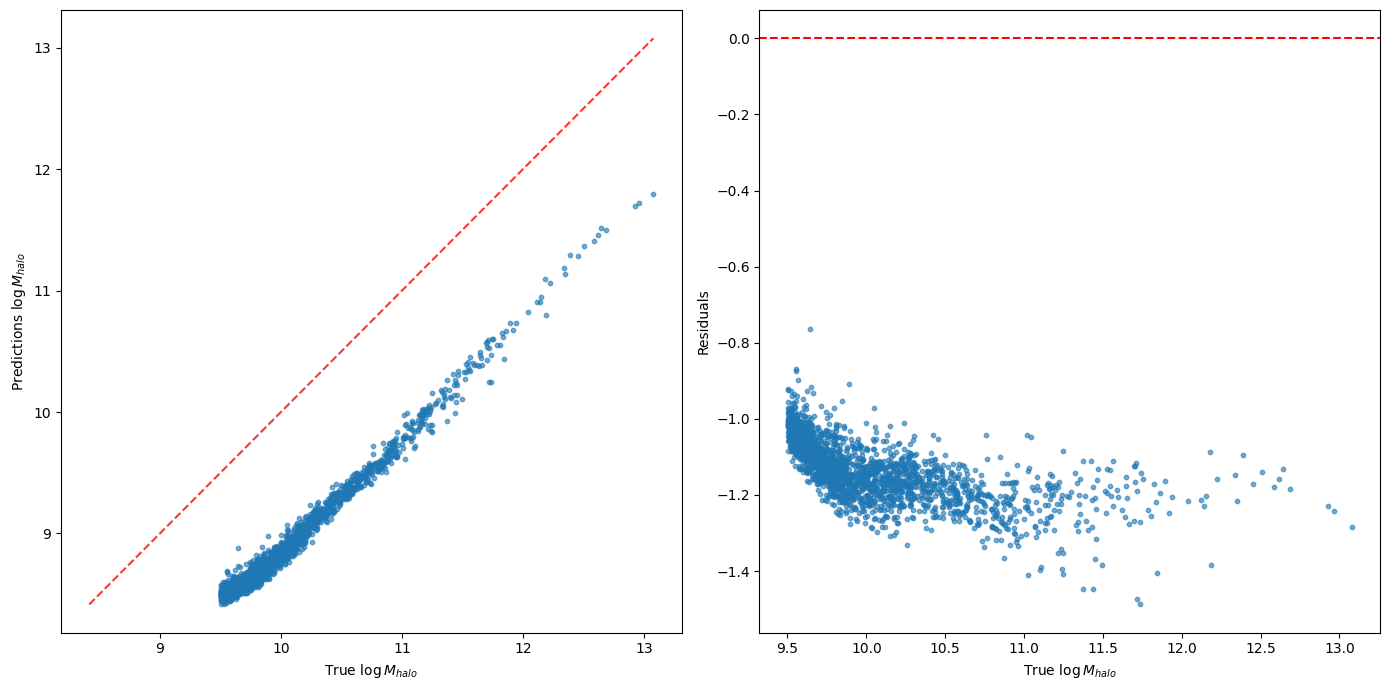

In [28]:
print("Getting predictions for the entire dataset...")
all_predictions_ws = model.predict(data_ws, device)
all_true_values_ws = data_ws.y.view(-1).cpu()
residuals_ws = all_predictions_ws - all_true_values_ws

fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].scatter(all_true_values_ws, all_predictions_ws, alpha=0.6, s=10)
ax[0].set_xlabel('True $\log M_{halo}$')
ax[0].set_ylabel('Predictions $\log M_{halo}$')

min_val_ws = min(all_true_values_ws.min(), all_predictions_ws.min())
max_val_ws = max(all_true_values_ws.max(), all_predictions_ws.max())
ax[0].plot([min_val_ws, max_val_ws], [min_val_ws, max_val_ws], 'r--', alpha=0.8)

ax[1].scatter(all_true_values_ws, residuals_ws, alpha=0.6, s=10)
ax[1].axhline(y=0, color='r', linestyle='--')
ax[1].set_xlabel('True $\log M_{halo}$')
ax[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

In [40]:
# Training loop
best_val_rmse_ba = float('inf')
train_losses_ba = []
val_rmses_ba = []
val_maes_ba = []

for epoch in range(num_epochs):
    # Training
    train_loss = train_epoch_full_graph(model, optimizer, data_ba, device)
    train_losses_ba.append(train_loss)
    
    # Evaluation
    val_rmse, val_mae, _, _ = evaluate_full_graph(model, data_ba, device)
    val_rmses_ba.append(val_rmse)
    val_maes_ba.append(val_mae)
    
    if val_rmse < best_val_rmse_ba:
        best_val_rmse_ba = val_rmse
        # Save best model
        torch.save(model.state_dict(), "../logs/best_model.pt")
    if epoch % 10 == 0:
        print(f'Epoch {epoch:03d}, Train Loss: {train_loss:.4f}, Val RMSE: {val_rmse:.4f}, Val MAE: {val_mae:.4f}')

print(f'Best validation RMSE: {best_val_rmse_ba:.4f}')

Epoch 000, Train Loss: 0.0228, Val RMSE: 1.1472, Val MAE: 1.1414
Epoch 010, Train Loss: 0.0220, Val RMSE: 1.1409, Val MAE: 1.1354
Epoch 020, Train Loss: 0.0185, Val RMSE: 1.1347, Val MAE: 1.1285
Epoch 030, Train Loss: 0.0199, Val RMSE: 1.1203, Val MAE: 1.1142
Epoch 040, Train Loss: 0.0197, Val RMSE: 1.1211, Val MAE: 1.1158
Epoch 050, Train Loss: 0.0195, Val RMSE: 1.0975, Val MAE: 1.0914
Epoch 060, Train Loss: 0.0181, Val RMSE: 1.1316, Val MAE: 1.1251
Epoch 070, Train Loss: 0.0176, Val RMSE: 1.1074, Val MAE: 1.1008
Epoch 080, Train Loss: 0.0185, Val RMSE: 1.1304, Val MAE: 1.1239
Epoch 090, Train Loss: 0.0182, Val RMSE: 1.1146, Val MAE: 1.1081
Best validation RMSE: 1.0926


<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_9112\2833020758.py:8: SyntaxWarning: invalid escape sequence '\l'
  ax[0].set_xlabel('True $\log M_{halo}$')
C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_9112\2833020758.py:9: SyntaxWarning: invalid escape sequence '\l'
  ax[0].set_ylabel('Predictions $\log M_{halo}$')
C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_9112\2833020758.py:17: SyntaxWarning: invalid escape sequence '\l'
  ax[1].set_xlabel('True $\log M_{halo}$')


Getting predictions for the entire dataset...


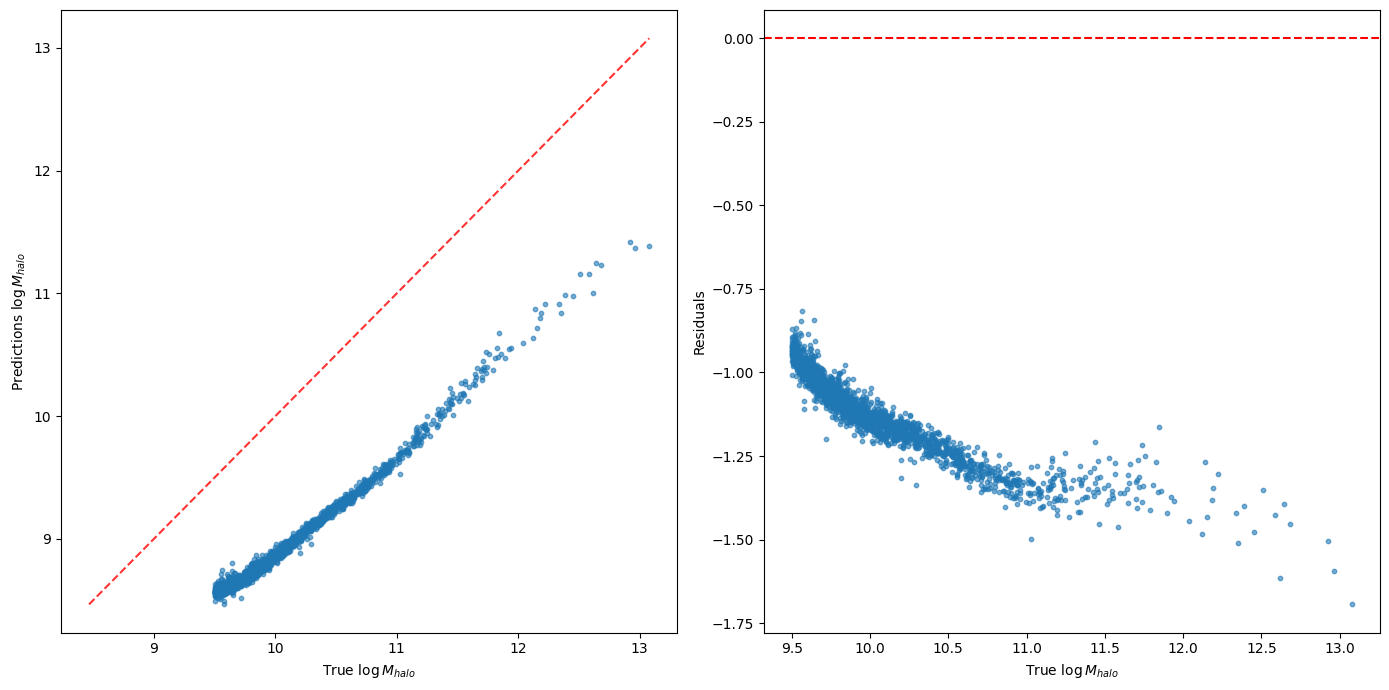

In [41]:
print("Getting predictions for the entire dataset...")
all_predictions_ba = model.predict(data_ba, device)
all_true_values_ba = data_ba.y.view(-1).cpu()
residuals_ba = all_predictions_ba - all_true_values_ba

fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].scatter(all_true_values_ba, all_predictions_ba, alpha=0.6, s=10)
ax[0].set_xlabel('True $\log M_{halo}$')
ax[0].set_ylabel('Predictions $\log M_{halo}$')

min_val_ba = min(all_true_values_ba.min(), all_predictions_ba.min())
max_val_ba = max(all_true_values_ba.max(), all_predictions_ba.max())
ax[0].plot([min_val_ba, max_val_ba], [min_val_ba, max_val_ba], 'r--', alpha=0.8)

ax[1].scatter(all_true_values_ba, residuals_ba, alpha=0.6, s=10)
ax[1].axhline(y=0, color='r', linestyle='--')
ax[1].set_xlabel('True $\log M_{halo}$')
ax[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()





In [30]:
# Initialize separate models for each graph
model_kdtree = GraphSAGENet(
    in_channels=data_kdtree.x.size(1),
    hidden_channels=hidden_channels,
    num_layers=num_layers,
    mlp_hidden=mlp_hidden
).to(device)

model_ws = GraphSAGENet(
    in_channels=data_ws.x.size(1),
    hidden_channels=hidden_channels,
    num_layers=num_layers,
    mlp_hidden=mlp_hidden
).to(device)

model_ba = GraphSAGENet(
    in_channels=data_ba.x.size(1),
    hidden_channels=hidden_channels,
    num_layers=num_layers,
    mlp_hidden=mlp_hidden
).to(device)

In [31]:
# Train model on KDTree graph
print("Training on KDTree graph...")
optimizer_kdtree = torch.optim.Adam(model_kdtree.parameters(), lr=learning_rate)
best_val_rmse_kdtree = float('inf')

for epoch in range(num_epochs):
    train_loss = train_epoch_full_graph(model_kdtree, optimizer_kdtree, data_kdtree, device)
    val_rmse, val_mae, _, _ = evaluate_full_graph(model_kdtree, data_kdtree, device)
    if val_rmse < best_val_rmse_kdtree:
        best_val_rmse_kdtree = val_rmse
    if epoch % 10 == 0:
        print(f'Epoch {epoch:03d}, Train Loss: {train_loss:.4f}, Val RMSE: {val_rmse:.4f}, Val MAE: {val_mae:.4f}')

print(f'Best validation RMSE (KDTree): {best_val_rmse_kdtree:.4f}\n')

Training on KDTree graph...
Epoch 000, Train Loss: 100.5009, Val RMSE: 9.7989, Val MAE: 9.7835
Epoch 010, Train Loss: 66.5447, Val RMSE: 7.8661, Val MAE: 7.8469
Epoch 020, Train Loss: 36.4539, Val RMSE: 5.6799, Val MAE: 5.6544
Epoch 030, Train Loss: 11.4859, Val RMSE: 2.8612, Val MAE: 2.8099
Epoch 040, Train Loss: 1.5449, Val RMSE: 0.8297, Val MAE: 0.7552
Epoch 050, Train Loss: 1.4961, Val RMSE: 0.5553, Val MAE: 0.4745
Epoch 060, Train Loss: 1.0554, Val RMSE: 0.4615, Val MAE: 0.3625
Epoch 070, Train Loss: 0.7061, Val RMSE: 0.2687, Val MAE: 0.1735
Epoch 080, Train Loss: 0.5489, Val RMSE: 0.1981, Val MAE: 0.1270
Epoch 090, Train Loss: 0.4971, Val RMSE: 0.1749, Val MAE: 0.1175
Best validation RMSE (KDTree): 0.1468



In [32]:
# Train model on Watts-Strogatz graph
print("Training on Watts-Strogatz graph...")
optimizer_ws = torch.optim.Adam(model_ws.parameters(), lr=learning_rate)
best_val_rmse_ws = float('inf')

for epoch in range(num_epochs):
    train_loss = train_epoch_full_graph(model_ws, optimizer_ws, data_ws, device)
    val_rmse, val_mae, _, _ = evaluate_full_graph(model_ws, data_ws, device)
    if val_rmse < best_val_rmse_ws:
        best_val_rmse_ws = val_rmse
    if epoch % 10 == 0:
        print(f'Epoch {epoch:03d}, Train Loss: {train_loss:.4f}, Val RMSE: {val_rmse:.4f}, Val MAE: {val_mae:.4f}')

print(f'Best validation RMSE (Watts-Strogatz): {best_val_rmse_ws:.4f}\n')

Training on Watts-Strogatz graph...
Epoch 000, Train Loss: 96.4947, Val RMSE: 9.6469, Val MAE: 9.6326
Epoch 010, Train Loss: 67.2728, Val RMSE: 7.9164, Val MAE: 7.8928
Epoch 020, Train Loss: 37.0323, Val RMSE: 5.6938, Val MAE: 5.6581
Epoch 030, Train Loss: 11.6182, Val RMSE: 2.8216, Val MAE: 2.7577
Epoch 040, Train Loss: 1.6233, Val RMSE: 0.8560, Val MAE: 0.7810
Epoch 050, Train Loss: 1.2556, Val RMSE: 0.5099, Val MAE: 0.4125
Epoch 060, Train Loss: 1.0185, Val RMSE: 0.4731, Val MAE: 0.3953
Epoch 070, Train Loss: 0.8653, Val RMSE: 0.3715, Val MAE: 0.2494
Epoch 080, Train Loss: 0.7214, Val RMSE: 0.2637, Val MAE: 0.2030
Epoch 090, Train Loss: 0.5743, Val RMSE: 0.2271, Val MAE: 0.1627
Best validation RMSE (Watts-Strogatz): 0.2149



In [33]:
# Train model on Barabási-Albert graph
print("Training on Barabási-Albert graph...")
optimizer_ba = torch.optim.Adam(model_ba.parameters(), lr=learning_rate)
best_val_rmse_ba = float('inf')

for epoch in range(num_epochs):
    train_loss = train_epoch_full_graph(model_ba, optimizer_ba, data_ba, device)
    val_rmse, val_mae, _, _ = evaluate_full_graph(model_ba, data_ba, device)
    if val_rmse < best_val_rmse_ba:
        best_val_rmse_ba = val_rmse
    if epoch % 10 == 0:
        print(f'Epoch {epoch:03d}, Train Loss: {train_loss:.4f}, Val RMSE: {val_rmse:.4f}, Val MAE: {val_mae:.4f}')

print(f'Best validation RMSE (Barabási-Albert): {best_val_rmse_ba:.4f}\n')

Training on Barabási-Albert graph...
Epoch 000, Train Loss: 105.7815, Val RMSE: 10.0723, Val MAE: 10.0583
Epoch 010, Train Loss: 77.9921, Val RMSE: 8.5950, Val MAE: 8.5779
Epoch 020, Train Loss: 53.4993, Val RMSE: 6.9816, Val MAE: 6.9608
Epoch 030, Train Loss: 25.8929, Val RMSE: 4.6527, Val MAE: 4.6214
Epoch 040, Train Loss: 5.0330, Val RMSE: 1.5810, Val MAE: 1.4856
Epoch 050, Train Loss: 2.5206, Val RMSE: 1.2200, Val MAE: 1.1388
Epoch 060, Train Loss: 1.4679, Val RMSE: 0.5892, Val MAE: 0.3888
Epoch 070, Train Loss: 1.0815, Val RMSE: 0.4901, Val MAE: 0.3539
Epoch 080, Train Loss: 0.8992, Val RMSE: 0.3878, Val MAE: 0.2954
Epoch 090, Train Loss: 0.6598, Val RMSE: 0.2210, Val MAE: 0.1416
Best validation RMSE (Barabási-Albert): 0.2096



<>:36: SyntaxWarning: invalid escape sequence '\l'
<>:37: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:53: SyntaxWarning: invalid escape sequence '\l'
<>:36: SyntaxWarning: invalid escape sequence '\l'
<>:37: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:53: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_18528\463397786.py:36: SyntaxWarning: invalid escape sequence '\l'
  axes[0].set_xlabel('True $\log M_{halo}$')
C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_18528\463397786.py:37: SyntaxWarning: invalid escape sequence '\l'
  axes[0].set_ylabel('Pred $\log M_{halo}$')
C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_18528\463397786.py:45: SyntaxWarning: invalid escape sequence '\l'
  axes[1].set_xlabel('True $\log M_{halo}$')
C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_18528\463397786.py:53: SyntaxWar

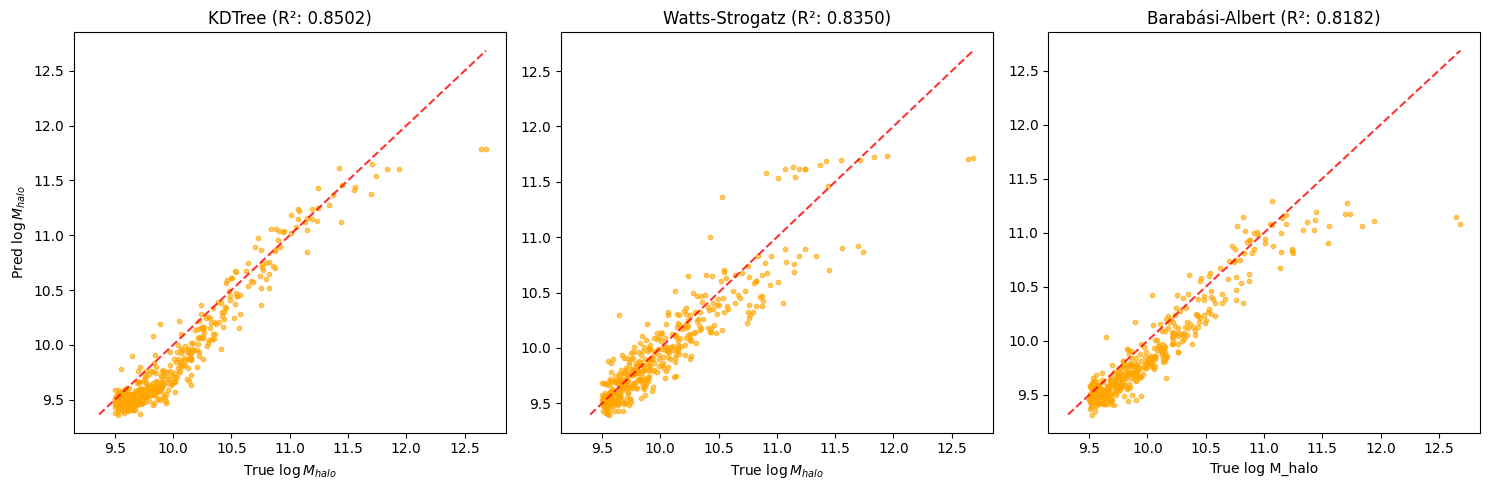

In [34]:
# Get predictions for test set only for each model
from sklearn.metrics import r2_score

# Get all predictions and filter by test_mask
all_pred_kdtree = model_kdtree.predict(data_kdtree, device)
all_true_kdtree = data_kdtree.y.view(-1).cpu()
test_mask_kdtree = data_kdtree.test_mask.cpu()
pred_kdtree = all_pred_kdtree[test_mask_kdtree]
true_kdtree = all_true_kdtree[test_mask_kdtree]

all_pred_ws = model_ws.predict(data_ws, device)
all_true_ws = data_ws.y.view(-1).cpu()
test_mask_ws = data_ws.test_mask.cpu()
pred_ws = all_pred_ws[test_mask_ws]
true_ws = all_true_ws[test_mask_ws]

all_pred_ba = model_ba.predict(data_ba, device)
all_true_ba = data_ba.y.view(-1).cpu()
test_mask_ba = data_ba.test_mask.cpu()
pred_ba = all_pred_ba[test_mask_ba]
true_ba = all_true_ba[test_mask_ba]

# Calculate R² for test set
r2_kdtree = r2_score(true_kdtree.numpy(), pred_kdtree.numpy())
r2_ws = r2_score(true_ws.numpy(), pred_ws.numpy())
r2_ba = r2_score(true_ba.numpy(), pred_ba.numpy())

# Create subplot with all three predictions (test set only)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True)

# KDTree plot
axes[0].scatter(true_kdtree, pred_kdtree, alpha=0.6, s=10, color='orange')
min_val_kdtree = min(true_kdtree.min(), pred_kdtree.min())
max_val_kdtree = max(true_kdtree.max(), pred_kdtree.max())
axes[0].plot([min_val_kdtree, max_val_kdtree], [min_val_kdtree, max_val_kdtree], 'r--', alpha=0.8, label='Perfect prediction')
axes[0].set_xlabel('True $\log M_{halo}$')
axes[0].set_ylabel('Pred $\log M_{halo}$')
axes[0].set_title(f'KDTree (R²: {r2_kdtree:.4f})')

# Watts-Strogatz plot
axes[1].scatter(true_ws, pred_ws, alpha=0.6, s=10, color='orange')
min_val_ws = min(true_ws.min(), pred_ws.min())
max_val_ws = max(true_ws.max(), pred_ws.max())
axes[1].plot([min_val_ws, max_val_ws], [min_val_ws, max_val_ws], 'r--', alpha=0.8, label='Perfect prediction')
axes[1].set_xlabel('True $\log M_{halo}$')
axes[1].set_title(f'Watts-Strogatz (R²: {r2_ws:.4f})')

# Barabási-Albert plot
axes[2].scatter(true_ba, pred_ba, alpha=0.6, s=10, color='orange')
min_val_ba = min(true_ba.min(), pred_ba.min())
max_val_ba = max(true_ba.max(), pred_ba.max())
axes[2].plot([min_val_ba, max_val_ba], [min_val_ba, max_val_ba], 'r--', alpha=0.8, label='Perfect prediction')
axes[2].set_xlabel('True $\log M_{halo}$')
axes[2].set_title(f'Barabási-Albert (R²: {r2_ba:.4f})')

plt.xlabel('True log M_halo')
plt.tight_layout()
plt.show()


In [ ]:
# Calculate R² for each model (test set only)
# Note: R² values are already calculated in the previous cell using test set predictions

# Convert to numpy arrays for display
true_kdtree_np = true_kdtree.numpy()
pred_kdtree_np = pred_kdtree.numpy()

true_ws_np = true_ws.numpy()
pred_ws_np = pred_ws.numpy()

true_ba_np = true_ba.numpy()
pred_ba_np = pred_ba.numpy()

# Print results (test set only)
print("R² Scores (Test Set Only):")
print(f"  KDTree:           {r2_kdtree:.6f}")
print(f"  Watts-Strogatz:  {r2_ws:.6f}")
print(f"  Barabási-Albert: {r2_ba:.6f}")
print()
print("Model Performance Summary (Test Set):")
print(f"{'Model':<20} {'RMSE':<10} {'R²':<10} {'Test Samples':<15}")
print("-" * 55)
print(f"{'KDTree':<20} {best_val_rmse_kdtree:<10.6f} {r2_kdtree:<10.6f} {len(pred_kdtree):<15}")
print(f"{'Watts-Strogatz':<20} {best_val_rmse_ws:<10.6f} {r2_ws:<10.6f} {len(pred_ws):<15}")
print(f"{'Barabási-Albert':<20} {best_val_rmse_ba:<10.6f} {r2_ba:<10.6f} {len(pred_ba):<15}")
